# K-NN (KNearst Neighbors) Algorithm

# 0/ Library Imports

In [1]:
"""
Library importation proecess for K-NN
This notebook is self-contained and initializes and installs the necessary libraries for the K-NN algorithm.
"""

# Numpy
%pip install pandas
import pandas as pd

# Sklearn
%pip install scikit-learn
# Import train_test_split function
from sklearn.model_selection import train_test_split
# Import StandardScaler for KNN
from sklearn.preprocessing import StandardScaler
# Import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Numpy
%pip install numpy
import numpy as np

# Matplotlib
%pip install matplotlib
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# 1/ Dataset Preparation

## 1.1/ Data Loading


In [2]:
"""
Dataset importation process for K-NN
Path to the dataset is '../datasets/all_dataset.csv'
"""

# Import [all_dataset.csv]
df = pd.read_csv('../datasets/all_dataset.csv')

# Show the first 5 rows of the dataset
df.head()

,timestamp,BLUE.HEXTECH_DRAGON.kills,BLUE.WATER_DRAGON.kills,BLUE.FIRE_DRAGON.kills,BLUE.EARTH_DRAGON.kills,BLUE.AIR_DRAGON.kills,BLUE.CHEMTECH_DRAGON.kills,BLUE.ELDER_DRAGON.kills,BLUE.RIFTHERALD.kills,BLUE.BARON_NASHOR.kills,...,soul_Mountain,soul_Ocean,BLUE.minionRatio,RED.minionRatio,BLUE.totalGoldRatio,RED.totalGoldRatio,BLUE.levelRatio,RED.levelRatio,BLUE.kda,RED.kda
0,0,0,0,0,0,0,0,0,0,0,...,0,0,NaN,NaN,inf,inf,inf,inf,NaN,NaN
1,60017,0,0,0,0,0,0,0,0,0,...,0,0,0.000000,0.000000,0.041655,0.041655,0.000083,0.000083,NaN,NaN
2,120046,0,0,0,0,0,0,0,0,0,...,0,0,0.000067,0.000092,0.024016,0.027648,0.000050,0.000050,0.000000,inf
3,180116,0,0,0,0,0,0,0,0,0,...,0,0,0.000333,0.000272,0.024978,0.026333,0.000072,0.000072,0.000000,inf
4,240131,0,0,0,0,0,0,0,0,0,...,0,0,0.000362,0.000346,0.026027,0.028230,0.000067,0.000075,0.666667,6.0


## 1.2/ Handle missing values and infinities & Data Preprocessing

In [3]:
"""
Handling missing values by setting them to 0
"""

# Replace missing values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
# Replace NaN with 0
df.fillna(0, inplace=True)

# Verify that missing values have been fixed
df.isnull().sum()

timestamp                        0
BLUE.HEXTECH_DRAGON.kills        0
BLUE.WATER_DRAGON.kills          0
BLUE.FIRE_DRAGON.kills           0
BLUE.EARTH_DRAGON.kills          0
BLUE.AIR_DRAGON.kills            0
BLUE.CHEMTECH_DRAGON.kills       0
BLUE.ELDER_DRAGON.kills          0
BLUE.RIFTHERALD.kills            0
BLUE.BARON_NASHOR.kills          0
BLUE.HORDE.kills                 0
BLUE.ATAKHAN.kills               0
RED.HEXTECH_DRAGON.kills         0
RED.WATER_DRAGON.kills           0
RED.FIRE_DRAGON.kills            0
RED.EARTH_DRAGON.kills           0
RED.AIR_DRAGON.kills             0
RED.CHEMTECH_DRAGON.kills        0
RED.ELDER_DRAGON.kills           0
RED.RIFTHERALD.kills             0
RED.BARON_NASHOR.kills           0
RED.HORDE.kills                  0
RED.ATAKHAN.kills                0
BLUE.TOWER_BUILDING.kills        0
RED.TOWER_BUILDING.kills         0
BLUE.INHIBITOR_BUILDING.kills    0
RED.INHIBITOR_BUILDING.kills     0
winner                           0
soul_Chemtech       

In [4]:
"""
Drop unnecessary columns
"""

# Drop timestamp column
df.drop(columns=["timestamp"], inplace=True)

## 1.3/ Target and Features

In [5]:
"""
Define features and target
The target is the 'winner' column
"""

# Define features and target
X = df.drop(columns=["winner"])  # Features
y = df["winner"]  # Target

# Verify that the target can hold only 2 unique values
assert len(np.unique(y)) == 2

## 1.4/ Train-Test Split

In [6]:
"""
Split the dataset into training and testing sets
Proportion: 80% training, 20% testing
"""

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.02, random_state=42)

# Print train and test set shapes
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(6455516, 40) (131746, 40) (6455516,) (131746,)


## 1.5/ Feature Scaling & Normalization

In [7]:
"""
Normalize the features using StandardScaler
Required for K-NN
"""

# Normalize features using StandardScaler
scaler = StandardScaler()

# StandardScaler is less sensitive to the presence of outliers
# It scales the data based on the mean and standard deviation

# Normalize training and testing features
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2/ K-NN Algorithm

In [8]:
"""
Initialize and train the K-NN model
Parameters:
- n_neighbors: 5
- n_jobs: -1

This model used 5 neighbors and all available processors for parallel processing.
"""

# Initialize the classifier
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

# Train the model
knn.fit(X_train, y_train)

KNeighborsClassifier(n_jobs=-1)

# 3/ Model Evaluation

In [9]:
"""
Predict how long it will take to predict the entire test set
This is done by predicting a subset of the test set and extrapolating the time it will take to predict the entire test set.
"""

import time

subset_size = 500  # Small sample for timing

# Start the timer
start_time = time.time()

# Predict the subset
y_pred = knn.predict(X_test[:subset_size])

# Verify that the prediction can hold only 2 unique values
assert len(np.unique(y_pred)) <= 2

# Stop the timer
end_time = time.time()

# Compute the estimated time for the full prediction
estimated_time = (end_time - start_time) * (len(X_test) / subset_size)
print(f"Estimated time for full prediction: {estimated_time:.2f} seconds => ({estimated_time / 60:.2f} minutes)")

Estimated time for full prediction: 331.48 seconds => (5.52 minutes)


### 3.1/ Predict using the model

In [10]:
"""
Predict the entire test set
"""

# Predict the entire test set
y_pred = knn.predict(X_test)

# Verify that the prediction may hold only 2 unique values
assert len(np.unique(y_pred)) <= 2

### 3.2/ Model Evaluation

********** KNN SCORES **********
Mean Absolute Error (MAE): 0.2033
Mean Squared Error (MSE): 0.2033
Root Mean Squared Error (RMSE): 0.4509
R^2 Score: 0.1863
f1 Score: 0.7877
Precision Score: 0.8032
Recall Score: 0.7728
**********************************
********** KNN ACCURACY **********
Accuracy:  0.7966921196848481
**********************************


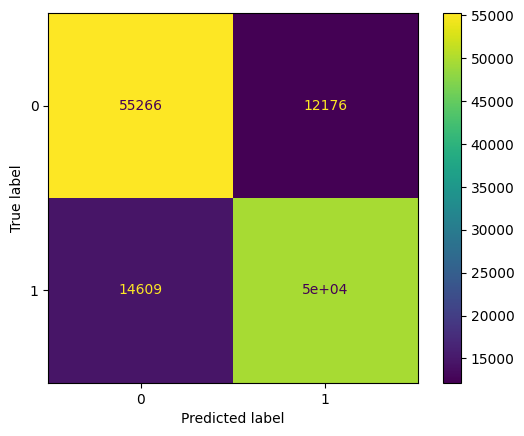

In [11]:
"""
Evaluate the model
Using :
- Mean Absolute Error
- Mean Squared Error
- Root Mean Squared Error
- R^2 Score
- F1 Score
- Precision Score
- Recall Score
"""

# Show statistics
# Evaluate the model using MAE, MSE, RMSE, R^2 Score, F1 score, Precision Score and Recall Score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)


print("********** KNN SCORES **********")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")
print(f"f1 Score: {f1:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print("**********************************")

# Get the final accuracy and the confusion matrix
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("********** KNN ACCURACY **********")
print(f"Accuracy: ", accuracy)
print("**********************************")

# Plot confusion matrix
cmatrix_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=knn.classes_)
cmatrix_display.plot() 

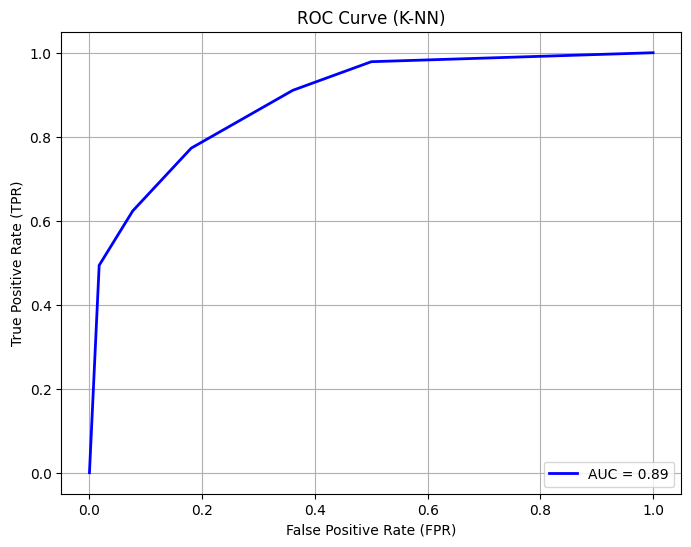

AUC-ROC Score: 0.8878


In [12]:
"""
ROC Curve & AUC-ROC Score
"""

# Get the probability estimates for the positive class
y_probs = knn.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Compute AUC-ROC score
auc_roc = roc_auc_score(y_test, y_probs)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc_roc:.2f}')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve (K-NN)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print AUC-ROC score
print(f"AUC-ROC Score: {auc_roc:.4f}")

# 4/ Fine Tuning the Model

In [ ]:
"""
Hyperparameter tuning
Using GridSearchCV to find the best n_neighbors value
"""

# Define the hyperparameter grid (No of neighbors from 1 to 10)
params = {'n_neighbors': range(1, 11)}

# Initialize GridSearchCV with cross-validation
grid_search = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),  # Use all available CPU cores
    params,
    cv=5,  # 5-fold cross-validation for robustness
    scoring='accuracy',  # Optimize for accuracy
    n_jobs=-1
)

# Fit GridSearchCV on the training data
grid_search.fit(X_train, y_train)

# Output the best hyperparameter value
best_k = grid_search.best_params_['n_neighbors']
print(f"Optimal number of neighbors (n_neighbors): {best_k}")